#**Ask A Manager Salary Survey 2021 - Exploratory Data Analysis**

####**Exploratory Data Analysis & Data Cleaning Project: "What Determines Pay?" — The Ask A Manager Salary Survey (2021)**




####**1.0. Project Overview**

This capstone is an exploratory data analysis (EDA) project. I worked with a large,  real-world survey dataset, cleaned it into an analysis-ready state, and used it to investigate business-style questions about pay and the factors associated with it.

The dataset was collected through an open online survey ("Ask A Manager", 2021) and reflects the realities of crowd-sourced data: free-text entries, inconsistent formatting, multiple ways of writing the same value, and missing responses.


#### **1.1. Mounting Google Drive and Loading the Dataset**

In [111]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load dataset
df = pd.read_csv('/content/drive/MyDrive/Ask A Manager Salary Survey 2021.csv')

#Let's confirm that it loaded correctly:
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Timestamp,How old are you?,What industry do you work in?,Job title,"If your job title needs additional context, please clarify here:","What is your annual salary? (You'll indicate the currency in a later question. If you are part-time or hourly, please enter an annualized equivalent -- what you would earn if you worked the job 40 hours a week, 52 weeks a year.)","How much additional monetary compensation do you get, if any (for example, bonuses or overtime in an average year)? Please only include monetary compensation here, not the value of benefits.",Please indicate the currency,"If ""Other,"" please indicate the currency here:","If your income needs additional context, please provide it here:",What country do you work in?,"If you're in the U.S., what state do you work in?",What city do you work in?,How many years of professional work experience do you have overall?,How many years of professional work experience do you have in your field?,What is your highest level of education completed?,What is your gender?,What is your race? (Choose all that apply.)
0,4/27/2021 11:02:10,25-34,Education (Higher Education),Research and Instruction Librarian,NaN,"55,000",0.0,USD,NaN,NaN,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,White
1,4/27/2021 11:02:22,25-34,Computing or Tech,Change & Internal Communications Manager,NaN,"54,600",4000.0,GBP,NaN,NaN,United Kingdom,NaN,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White
2,4/27/2021 11:02:38,25-34,"Accounting, Banking & Finance",Marketing Specialist,NaN,"34,000",NaN,USD,NaN,NaN,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White
3,4/27/2021 11:02:41,25-34,Nonprofits,Program Manager,NaN,"62,000",3000.0,USD,NaN,NaN,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White
4,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",Accounting Manager,NaN,"60,000",7000.0,USD,NaN,NaN,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,White


####**1.2. Columns Renaming**

As I carry on with my analysis, I would have to occasionally make references to the columns in this data, and because the original column names are questions in full sentences, referencing these columns would be quite tedious.

To make my analysis easier and neater, I would be renaming each column to something that would perfectly represent what each column is about.

In [112]:
df.columns = [
    'Timestamp',
    'Age',
    'Industry',
    'Job_Title',
    'Job_Title_Context',
    'Annual_Salary',
    'Bonus',
    'Currency',
    'Currency_Other',
    'Income_Context',
    'Country',
    'State',
    'City',
    'Overall_Years_Experience',
    'Field_Years_Experience',
    'Education',
    'Gender',
    'Race'
]
df.head()

,Timestamp,Age,Industry,Job_Title,Job_Title_Context,Annual_Salary,Bonus,Currency,Currency_Other,Income_Context,Country,State,City,Overall_Years_Experience,Field_Years_Experience,Education,Gender,Race
0,4/27/2021 11:02:10,25-34,Education (Higher Education),Research and Instruction Librarian,NaN,"55,000",0.0,USD,NaN,NaN,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,White
1,4/27/2021 11:02:22,25-34,Computing or Tech,Change & Internal Communications Manager,NaN,"54,600",4000.0,GBP,NaN,NaN,United Kingdom,NaN,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White
2,4/27/2021 11:02:38,25-34,"Accounting, Banking & Finance",Marketing Specialist,NaN,"34,000",NaN,USD,NaN,NaN,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White
3,4/27/2021 11:02:41,25-34,Nonprofits,Program Manager,NaN,"62,000",3000.0,USD,NaN,NaN,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White
4,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",Accounting Manager,NaN,"60,000",7000.0,USD,NaN,NaN,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,White


####**1.3. Understanding the Data**

Before any cleaning or analysis can be done, I need to have an overview of the dataset I'm working with. This overview includes knowing the number of rows and columns in the data, finding out if there are missing/null values in any of the rows/columns, and ascertaining whether or not the data types are consistent with the column they belong to.

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27940 entries, 0 to 27939
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Timestamp                 27940 non-null  object 
 1   Age                       27940 non-null  object 
 2   Industry                  27868 non-null  object 
 3   Job_Title                 27940 non-null  object 
 4   Job_Title_Context         7232 non-null   object 
 5   Annual_Salary             27940 non-null  object 
 6   Bonus                     20687 non-null  float64
 7   Currency                  27940 non-null  object 
 8   Currency_Other            195 non-null    object 
 9   Income_Context            3033 non-null   object 
 10  Country                   27940 non-null  object 
 11  State                     22959 non-null  object 
 12  City                      27861 non-null  object 
 13  Overall_Years_Experience  27940 non-null  object 
 14  Field_

In [114]:
# I also need to have an idea of the numerical/statistical components of the dataset.
df.describe()

,Bonus
count,2.068700e+04
mean,1.821158e+04
std,8.356437e+05
min,0.000000e+00
25%,0.000000e+00
50%,2.000000e+03
75%,1.000000e+04
max,1.200000e+08


####**2.0. Data Cleaning**

Now that I have an overview of the dataset, I can identify the areas that need to be cleaned before the analysis can take place.

There are missing values in some of the columns, such as Industry, Education, State, Bonus, etc. A few other columns are almost empty, such as Job_Title_Context, and can therefore be removed from the dataset.

There are also columns that need to be converted to more appropriate data types, such as Timestamp and Annual_Salary.

####**2.1. Handling the Null Values**

In [115]:
#I started my cleaning by handling the missing or null values first.

#1. I will drop columns like Job_Title_Context, Currency_Other, and Income_Context because most of the rows in these columns are empty.
df = df.drop(columns=['Job_Title_Context', 'Currency_Other', 'Income_Context'])

#2. There are columns with a few number of nulls. I will drop these rows since dropping them won't affect my analysis later.
df = df.dropna(subset=['Industry', 'City', 'Education', 'Gender', 'Race'])

Some columns have quite a reasonable amount of null values. I studied these columns briefly to understand what they represented and the sort of data that is required to be in such columns. Doing this was just to decide the best way to fill in the empty rows in these columns.

For the 'State' column, the question which was used as the original column header implied that the respondents should provide their state
if they were based in the US. Therefore, there is a reasonable basis for treating null values in this column as respondents
who were not based in the US. I will fill the empty rows in this column with 'Not Applicable'.

For the 'Bonus' column, I assumed that null values meant the respondent got no bonus at work. I will therefore fill the empty rows with 0 so that the column can be used for numerical calculations.

In [116]:
df['State'] = df['State'].fillna('Not Applicable')
df['Bonus'] = df['Bonus'].fillna(0)
df.columns

Index(['Timestamp', 'Age', 'Industry', 'Job_Title', 'Annual_Salary', 'Bonus',
       'Currency', 'Country', 'State', 'City', 'Overall_Years_Experience',
       'Field_Years_Experience', 'Education', 'Gender', 'Race'],
      dtype='object')

####**2.2. Conversion of Columns to Appropriate Data Types**

Several columns in the dataset were stored in data types that were not appropriate for analysis. For example, 'Annual_Salary' was stored as text with comma thousands-separators rather than as a numerical value. Timestamp, which shows the exact date and time that each response was recorded, was also stored as an object and needed to be converted to datetime.

Experience and Age were provided as text buckets rather than individual numerical values, so they were converted to ordered categorical variables to preserve their natural sequence.

These conversions make the affected columns more suitable for calculationa, comparisons, and further analysis.

In [117]:
#1. Convert Timestamp from object dtype to datetime.
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

#2. Since the values in the Age column are grouped, I will convert the dtype to an ordered categorical type.
age_order = ['under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65 or over']
df['Age'] = pd.Categorical(df['Age'], categories=age_order, ordered=True)

#3. Convert Annual_Salary to numeric.
df['Annual_Salary'] = df['Annual_Salary'].astype(str).str.replace(',', '').str.replace('$', '')
df['Annual_Salary'] = pd.to_numeric(df['Annual_Salary'], errors='coerce')

#4. Convert Bonus to numeric.
df['Bonus'] = df['Bonus'].astype('int64')

#5. Convert Overall_Years_Experience & Field_Years_Experience to ordered category.
exp_order = ['1 year or less', '2 - 4 years', '5-7 years', '8 - 10 years', '11 - 20 years', '21 - 30 years', '31 - 40 years',
             '41 years or more']
df['Overall_Years_Experience'] = pd.Categorical(df['Overall_Years_Experience'], categories=exp_order, ordered=True)
df['Field_Years_Experience'] = pd.Categorical(df['Field_Years_Experience'], categories=exp_order, ordered=True)

#6. Convert Education to ordered category as well.
edu_order = ["High School", "Some college", "College degree", "Master's degree", "PhD", "Professional degree (MD, JD, etc.)"]
df['Education'] = pd.Categorical(df['Education'], categories=edu_order, ordered=True)

#7. Confirm new dtype of each column.
df.dtypes

,0
Timestamp,datetime64[ns]
Age,category
Industry,object
Job_Title,object
Annual_Salary,int64
Bonus,int64
Currency,object
Country,object
State,object
City,object


####**2.3. Deep Cleaning**

Now that the columns have been stored in their appropriate data types, it's time to move on to deeper cleaning.

Most of the columns contain messy and highly inconsistent entries, ranging from wrong spellings to implausible numerical values. Some respondents also appear to have misunderstood certain column questions. For example, in the 'Country' column, some repondents entered their nationality or the country their organisation is located, instead of the country where they work or are based. Country names are also extremely inconsistent. The United States alone appears under many different spellings, abbreviations, and cases ("USA", "US", "U.S.", "United States", "United states", "usa", "Usa", "United States of America", e.t.c.) across 362 raw unique country values. These must be standardised before any location-based comparison can be performed meaningful.


####**2.3.1. Country Column**

In [118]:
# 'Country'represents where the respondents work from.
# This column has typos, abbreviations, and even full sentences.
# I created a dictionary to map all these to more common variants.

# Before creating the dictionary, I will standardise the column by converting all letters to lowercase and removing leading and trailing whitespaces.
df['Country'] = df['Country'].astype(str).str.strip().str.lower()

# Next, I will create a dictionary to map all the countries to common variants.

Some of the values in the 'Country' column are not countries. They are either regions, cities, states or territories. Examples include: California, Virginia, San Francisco, e.t.c.
I decided to map these values to their respective countries.
I also grouped territories and crown dependencies (e.g: Channel Islands, Cayman Islands, Isle of Man) with their sovereign country.

There are other values that are neither states nor cities, but they also don't belong in a 'Country' column.
Some of these values include: Europe, APAC, and full sentences.
I decided to map these values to 'Unknown'.

In [119]:
country_map = {
    # United States variants:
    'us': 'united states', 'u.s.': 'united states', 'u.s.a.': 'united states', 'usa': 'united states', 'u.s.a.': 'united states',
    'usab': 'united states', 'usat': 'united states', 'usaa': 'united states', 'usa ': 'united states', 'united states': 'united states',
    'united stated': 'united states', 'united statess': 'united states', 'united statew': 'united states', 'united sttes': 'united states',
    'united stares': 'united states', 'united states of america': 'united states', 'united states of american': 'united states',
    'unites states': 'united states', 'unitef stated': 'united states', 'unitied states': 'united states', 'uniteed states': 'united states',
    'untied states': 'united states', 'uniter statez': 'united states', 'united stateds': 'united states', 'hartford': 'united states',
    'united states- puerto rico': 'united states', 'united states is america': 'united states', 'america': 'united states',
    'u. s': 'united states', 'american': 'united states', 'u.s.a ': 'united states', 'the united states': 'united states',
    'united state of america': 'united states', 'united state': 'united states', 'u.s.a': 'united states', 'u.s>': 'united states',
    'u.s.a.': 'united states', 'u.s.a': 'united states', 'isa': 'united states', 'united sates': 'united states', 'i.s.': 'united states',
    'uniited states': 'united states', 'usa-- virgin islands': 'united states', 'united statws': 'united states', 'is': 'united states',
    'u.s': 'united states', 'u. s.': 'united states', 'us of a': 'united states', 'u.sa': 'united states', '🇺🇸': 'united states',
    'united sates of america': 'united states', 'united statea': 'united states', 'united statees': 'united states',
    'united states (i work from home and my clients are all over the us/canada/pr': 'united states', 'virginia': 'united states',
    'united states ': 'united states', 'unted states': 'united states', 'united statesp': 'united states', 'united stattes': 'united states',
    'uniyed states': 'united states', 'uniyes states': 'united states', 'united states of americas': 'united states', 'u.a.': 'united states',
    'united status': 'united states', 'california': 'united states', 'san francisco': 'united states', 'puerto rico': 'united states',
    'unite states': 'united states', 'the us': 'united states', 'uss': 'united states', 'usa tomorrow': 'united states',
    'unitedstates': 'united states', 'united statues': 'united states', 'usd': 'united states', 'united statss': 'united states',
    'i work for a uae-based organization, though i am personally in the us.': 'united states', "usa, but for foreign gov't": 'united states',
    'united  states': 'united states',

    # United Kingdom variants:
    'unites kingdom': 'united kingdom', 'uk': 'united kingdom', 'u.k.': 'united kingdom', 'u.k': 'united kingdom', 'england': 'united kingdom',
    'england, gb': 'united kingdom', 'england, united kingdom': 'united kingdom', 'scotland, uk': 'united kingdom', 'wales': 'united kingdom',
    'wales (uk)': 'united kingdom', 'wales (united kingdom)': 'united kingdom', 'wales, uk': 'united kingdom', 'englang': 'united kingdom',
    'united kingdomk': 'united kingdom', 'united kingdom': 'united kingdom', 'northern ireland': 'united kingdom',
    'northern ireland, united kingdom': 'united kingdom', 'uk (northern ireland)': 'united kingdom', 'uk (england)': 'united kingdom',
    'uk for u.s. company': 'united kingdom', 'uk, remote': 'united kingdom', 'jersey, channel islands': 'united kingdom',
    'u.k. (northern england)': 'united kingdom', 'isle of man': 'united kingdom', 'scotland': 'united kingdom',
    'great britain': 'united kingdom', 'bermuda': 'united kingdom', 'scotland, gb': 'united kingdom', 'wales, gb': 'united kingdom',
    'england/uk': 'united kingdom', 'england, uk.': 'united kingdom', 'britain': 'united kingdom', 'united kingdom (england)': 'united kingdom',
    'united kingdom (gb)': 'united kingdom', 'united kingdom.': 'united kingdom', 'cayman islands': 'united kingdom',
    'channel islands': 'united kingdom', 'united kingdom, gb': 'united kingdom', 'united kingdom, uk': 'united kingdom',
    'jersey': 'united kingdom', 'england, uk': 'united kingdom', 'uk, but for globally fully remote company': 'united kingdom',
    'united kindom': 'united kingdom',

    # Canada variants:
    'canada': 'canada', 'canada, ottawa, ontario': 'canada', 'canadw': 'canada', 'canada ': 'canada', 'canada, ontario': 'canada',
    'can': 'canada', 'canda': 'canada', 'canada, ontario, ca': 'canada', 'csnada': 'canada', 'canad': 'canada', 'canadá': 'canada',
    'i am located in canada but i work for a company in the us': 'canada',

    # New Zealand variants:
    'nz': 'new zealand', 'new zealand': 'new zealand', 'new zealand aotearoa': 'new zealand', 'aotearoa new zealand': 'new zealand',
    'new zealand ': 'new zealand',

    # Netherlands variants:
    'nl': 'netherlands', 'the netherlands': 'netherlands', 'nederland': 'netherlands', 'the netherlands ': 'netherlands',
    'netherlands': 'netherlands',

    # Other common countries:
    'uae': 'united arab emirates', 'south africa': 'south africa', 'south korea': 'south korea', 'czech republic': 'czech republic',
    'hong kong': 'china', 'switzerland': 'switzerland', 'mexico': 'mexico', 'singapore': 'singapore', 'taiwan ': 'taiwan',
    'russia': 'russia', 'australia': 'australia', 'finland': 'finland', 'france': 'france', 'germany': 'germany', 'india': 'india',
    'italy': 'italy', 'japan': 'japan', 'malaysia': 'malaysia', 'argentina': 'argentina', 'denmark': 'denmark', 'spain': 'spain',
    'turkey': 'turkey', 'brazil': 'brazil', 'belgium': 'belgium', 'poland': 'poland', 'egypt': 'egypt', 'czechia': 'czech republic',
    'sweden': 'sweden', 'kuwait': 'kuwait', 'hungary': 'hungary', 'sri lanka': 'sri lanka', 'portugal': 'portugal', 'romania': 'romania',
    'israel': 'israel', 'israel ': 'israel', 'nigeria': 'nigeria', 'greece': 'greece', 'norway': 'norway', 'austria': 'austria',
    'luxembourg': 'luxembourg', 'colombia': 'colombia', 'singapore ': 'singapore', 'rwanda': 'rwanda', 'catalonia': 'spain',
    'trinidad and tobago': 'trinidad and tobago', 'thailand ': 'thailand', 'latvia ': 'latvia', 'romania ': 'romania', 'chile': 'chile',
    'serbia ': 'serbia', 'afghanistan': 'afghanistan', 'vietnam': 'vietnam', 'bangladesh': 'bangladesh', 'bulgaria': 'bulgaria',
    'lithuania': 'lithuania', 'cuba': 'cuba', 'eritrea': 'eritrea', 'taiwan': 'taiwan', 'ecuador': 'ecuador', 'indonesia': 'indonesia',
    'slovenia': 'slovenia', "cote d'ivoire": "cote d'ivoire", 'saudi arabia': 'saudi arabia', 'rwanda': 'rwanda', 'luxemburg': 'luxembourg',
    'liechtenstein ': 'liechtenstein', 'cyprus': 'cyprus', 'jordan': 'jordan', 'croatia': 'croatia', 'portugal ': 'portugal',
    'ecuador': 'ecuador', 'morocco': 'morocco', 'estonia': 'estonia', 'malta': 'malta', 'uruguay': 'uruguay', 'panamá': 'panamá',
    'qatar': 'qatar', 'costa rica': 'costa rica', 'the bahamas': 'the bahamas', 'sierra leone': 'sierra leone', 'slovakia': 'slovakia',
    'danmark': 'denmark', 'cambodia': 'cambodia', 'russia': 'russia', 'philippines ': 'philippines', 'serbia': 'serbia', 'brasil': 'brazil',
    'italy (south)': 'italy', 'mainland china': 'china', 'australi': 'australia', 'congo': 'congo', 'ghana': 'ghana', 'uganda': 'uganda',
    'pakistan': 'pakistan', 'zimbabwe': 'zimbabwe', 'méxico': 'mexico', 'jamaica': 'jamaica', 'kenya': 'kenya', 'hong konh': 'china',
    'argentina but my org is in thailand': 'argentina', 'company in germany. i work from pakistan.': 'pakistan', 'ukraine': 'ukraine',
    'australian': 'australia', 'japan, us gov position': 'japan', 'austria, but i work remotely for a dutch/british company': 'austria',
    'ireland': 'ireland', 'remote (philippines)': 'philippines',

    # Unknown variants:
    'contracts': 'unknown', 'unknown': 'unknown', 'remote': 'unknown', 'currently finance': 'unknown', 'remotely': 'unknown', 'uxz': 'unknown',
    'remotely ': 'unknown', 'canada and usa': 'unknown', '$2,175.84/year is deducted for benefits': 'unknown', 'international': 'unknown',
    'for the united states government, but posted overseas': 'unknown', 'africa': 'unknown', 'n/a (remote from wherever i want)': 'unknown',
    'us govt employee overseas, country withheld': 'unknown', 'ua': 'unknown', 'from new zealand but on projects across apac': 'unknown',
    'y': 'unknown', 'united y': 'unknown', 'europe': 'unknown', 'na': 'unknown', 'policy': 'unknown',
    'i was brought in on this salary to help with the ehr and very quickly was promoted to current position but compensation was not altered.': 'unknown',
    "i earn commission on sales. if i meet quota, i'm guaranteed another 16k min. last year i earned an additional 27k. it's not uncommon for people in my space to earn 100k+ after commission.": 'unknown',
    "we don't get raises, we get quarterly bonuses, but they periodically asses income in the area you work, so i got a raise because a 3rd party assessment showed i was paid too little for the area we were located": 'unknown',
    'worldwide (based in us but short term trips aroudn the world)': 'unknown', 'from romania, but for an us based company': 'unknown',
    "i work for an us based company but i'm from argentina.": 'unknown', 'global': 'unknown',

}

df['Country'] = df['Country'].replace(country_map)

sorted(df['Country'].unique())

['afghanistan',
 'argentina',
 'australia',
 'austria',
 'bangladesh',
 'belgium',
 'brazil',
 'bulgaria',
 'cambodia',
 'canada',
 'chile',
 'china',
 'colombia',
 'congo',
 'costa rica',
 "cote d'ivoire",
 'croatia',
 'cuba',
 'cyprus',
 'czech republic',
 'denmark',
 'ecuador',
 'eritrea',
 'estonia',
 'finland',
 'france',
 'germany',
 'ghana',
 'greece',
 'hungary',
 'india',
 'indonesia',
 'ireland',
 'israel',
 'italy',
 'jamaica',
 'japan',
 'jordan',
 'kenya',
 'kuwait',
 'latvia',
 'liechtenstein',
 'lithuania',
 'luxembourg',
 'malaysia',
 'malta',
 'mexico',
 'morocco',
 'netherlands',
 'new zealand',
 'nigeria',
 'norway',
 'pakistan',
 'panamá',
 'philippines',
 'poland',
 'portugal',
 'qatar',
 'romania',
 'russia',
 'rwanda',
 'saudi arabia',
 'serbia',
 'sierra leone',
 'singapore',
 'slovakia',
 'slovenia',
 'south africa',
 'south korea',
 'spain',
 'sri lanka',
 'sweden',
 'switzerland',
 'taiwan',
 'thailand',
 'the bahamas',
 'trinidad and tobago',
 'turkey',
 'ug

####**2.3.1.1. Restricting the 'Country' Column to Three Selected Countries**

In [120]:
# I am doing this to restrict my analysis to a sensible subset (US, UK, Canada).
target_countries = ['united states', 'united kingdom', 'canada']
count = df['Country'].isin(target_countries).sum()
total = len(df)
percentage = (count/total) * 100

print(f"Rows matching US/UK/Canada: {count} out of {total} ({percentage:.2f}%)")

Rows matching US/UK/Canada: 25855 out of 27349 (94.54%)


The result shows that 94.54% of the entire dataset (25,855 out of 27,349 rows) came from people working in the US, UK, and Canada.
Restricting the analysis to these three countries excludes 5.46% of respondents while allowing the analysis to focus on the three most represented countries and their currencies: USD, GBP, and CAD.

In [121]:
# Restrict the analysis to the three selected countries.
df = df[df['Country'].isin(target_countries)]
df['Country'].unique()

array(['united states', 'united kingdom', 'canada'], dtype=object)

####**2.3.2. State, City, and Race Columns**

####**2.3.2.1. State Column**

For the 'State' column, a few respondents entered multiple states. This may indicate that some respondents work across multiple locations or have another reason for reporting more than one state.

 For the purpose of this analysis, I will create a new column called 'Primary_State', using the first listed state in the 'State' column as the 'Primary_State'. I will then standardise the values by removing leading and trailing whitespaces and converting the text to lowercase.

In [122]:
df['Primary_State'] = df['State'].str.split(',').str[0].str.strip()
df['Primary_State'] = df['Primary_State'].astype(str).str.strip().str.lower()
df['Primary_State'].unique()

array(['massachusetts', 'not applicable', 'tennessee', 'wisconsin',
       'south carolina', 'new hampshire', 'arizona', 'missouri',
       'florida', 'pennsylvania', 'michigan', 'illinois', 'california',
       'georgia', 'ohio', 'district of columbia', 'maryland', 'texas',
       'minnesota', 'virginia', 'north carolina', 'new york',
       'new jersey', 'rhode island', 'colorado', 'oregon', 'washington',
       'indiana', 'iowa', 'nebraska', 'oklahoma', 'maine', 'connecticut',
       'south dakota', 'west virginia', 'idaho', 'louisiana', 'montana',
       'kentucky', 'north dakota', 'kansas', 'vermont', 'arkansas',
       'alabama', 'nevada', 'delaware', 'new mexico', 'hawaii', 'utah',
       'mississippi', 'alaska', 'wyoming'], dtype=object)

####**2.3.2.2. City Column**


'City' has an extremely large number of unique values which will make extensive cleaning difficult. Because this column is not particularly necessary for my analysis, I won't be performing any major cleaning on it. I will limit the cleaning to removing leading and trailing whitespaces and converting the text to lowercase for consistency.

In [123]:
df['City'] = df['City'].astype(str).str.strip().str.lower()

####**2.3.2.3. Race Column**

Race is a multi-select column, with each cell containing one or more categories that are separated by commas. This column contains inconsistent formatting and reponses that sometimes include multiple racial identities.

Because part of my analysis has to do with the race of respondents, I will standardise the text and group similar responses into broader categories to make the data suitable for analysis. These categories will represent the responses provided by participants and should not be interpreted as mutually exclusive measures of race.

In [124]:
# First remove leading & trailing whitespaces and convert to lowercase for consistency.
df['Race'] = df['Race'].astype(str).str.strip().str.lower()

# Define the actual valid race categories (as they appear in the original survey options).
valid_races = [
    'white',
    'black or african american',
    'asian or asian american',
    'hispanic, latino, or spanish origin',
    'middle eastern or northern african',
    'native american or alaska native',
    'another option not listed here or prefer not to answer'
]

# Create one binary column per race category:
for race in valid_races:
  col_name = 'Race_' + race.split(' or ')[0].replace(' ', '_').replace(',', '')[:20]
  df[col_name] = df['Race'].str.contains(race, regex=False, na=False).astype(int)

  # Check the result:
  df.filter(like='Race_').sum()

df.head()

,Timestamp,Age,Industry,Job_Title,Annual_Salary,Bonus,Currency,Country,State,City,...,Gender,Race,Primary_State,Race_white,Race_black,Race_asian,Race_hispanic_latino,Race_middle_eastern,Race_native_american,Race_another_option_not_l
0,2021-04-27 11:02:10,25-34,Education (Higher Education),Research and Instruction Librarian,55000,0,USD,united states,Massachusetts,boston,...,Woman,white,massachusetts,1,0,0,0,0,0,0
1,2021-04-27 11:02:22,25-34,Computing or Tech,Change & Internal Communications Manager,54600,4000,GBP,united kingdom,Not Applicable,cambridge,...,Non-binary,white,not applicable,1,0,0,0,0,0,0
2,2021-04-27 11:02:38,25-34,"Accounting, Banking & Finance",Marketing Specialist,34000,0,USD,united states,Tennessee,chattanooga,...,Woman,white,tennessee,1,0,0,0,0,0,0
3,2021-04-27 11:02:41,25-34,Nonprofits,Program Manager,62000,3000,USD,united states,Wisconsin,milwaukee,...,Woman,white,wisconsin,1,0,0,0,0,0,0
4,2021-04-27 11:02:42,25-34,"Accounting, Banking & Finance",Accounting Manager,60000,7000,USD,united states,South Carolina,greenville,...,Woman,white,south carolina,1,0,0,0,0,0,0


####**2.3.3. Overall_Years_Experience & Field_Years_Experience Columns**

Earlier, I converted both Overall_Years_Experience & Field_Years_Experience dtypes to ordered category so that te natural progression of experience levels remains preserved during analysis. Now, I am going to derive a numerical midpoint for each of the categories in these columns. This would be useful for later comparisons.


####**2.3.3.1. Overall_Years_Experience Column**


In [125]:
df['Overall_Years_Experience'].unique()

# I will map each category to their midpoint.
# To do this; midpoint = (a + b)/2
# For example, if a category is: 5 - 7 years, midpoint = (5 + 7)/2 --> 6

experience_midpoints ={
    '1 year or less': 0.5,
    '2 - 4 years': 3,
    '5-7 years': 6,
    '8 - 10 years': 9,
    '11 - 20 years': 15.5,
    '21 - 30 years': 25.5,
    '31 - 40 years': 35.5,
    '41 years or more': 43
}

df['Overall_Years_Experience_Midpoint'] = df['Overall_Years_Experience'].astype(str).map(experience_midpoints)
df['Overall_Years_Experience_Midpoint'].isnull().sum()

np.int64(0)

####**2.3.3.2. Field_Years_Experience Column**

In [126]:
df['Field_Years_Experience'].unique()

# Derive midpoints:
experience_midpoints ={
    '1 year or less': 0.5,
    '2 - 4 years': 3,
    '5-7 years': 6,
    '8 - 10 years': 9,
    '11 - 20 years': 15.5,
    '21 - 30 years': 25.5,
    '31 - 40 years': 35.5,
    '41 years or more': 43
}

df['Field_Years_Experience_Midpoint'] = df['Field_Years_Experience'].astype(str).map(experience_midpoints)
df['Field_Years_Experience_Midpoint'].isnull().sum()

np.int64(0)

Now that I have derived the midpoints of both the 'Overall_Years_Experience' and the 'Field_Experience', I will create an 'Experience_Gap' column. This column is necessary because, later on, I would love to analyse if there is a "sweet spot" between total work experience and years in the specific field — i.e. does having more years in-role beyond overall experience relate differently to salary than the reverse?

In [127]:
df['Experience_Gap'] = df['Overall_Years_Experience_Midpoint'] - df['Field_Years_Experience_Midpoint']
df['Experience_Gap'].describe()

,Experience_Gap
count,25855.000000
mean,3.481087
std,5.384729
min,-40.000000
25%,0.000000
50%,0.000000
75%,6.500000
max,42.500000


In [128]:
# Get the total number of rows in the dataset and compare it with the number of affected rows:
(df['Experience_Gap'] < 0).sum()

['Experience_Gap'].count()

np.int64(25855)

**Note on Experience_Gap outliers:**

After running the Experience_Gap code, I discovered that the min read -40, which means at least one respondent reported having more field_years_experience than overall_years_experience, which isn't possible.

To check how many rows had a value like this, I ran a code on the Experience_Gap column for python to return the number of rows with values < 0. The result was 234.

Given that the total number of rows in this column is 25855, having 234 affected rows is unlikely to meaningfully affect the overall analysis of the experience "sweet spot". For this reason, the rows were retained rather than dropped.

####**2.3.4. Currency Column**

In [129]:
# First check what currencies are actually in the dataset.
df['Currency'].value_counts()

,count
Currency,
USD,22665
CAD,1625
GBP,1540
Other,16
EUR,5
CHF,1
SEK,1
JPY,1
AUD/NZD,1


From the result, USD is the vast majority, with 22,665 responses, followed by CAD (1,625) then GBP (1,540).

The remaining currency categories (others, EUR, CHF, SEK, JPY, and AUD/NZD) account for 25 responses in total, which represents a very small proportion of the dataset, and since I have restricted the countries to only the US, the UK, and Canada, I will retain USD, GBP, and CAD and exclude the remaining currency categories.

I will then convert GBP and CAD to USD (since that is the most-used currency in the column) using approximate fixed exchange rates so that salaries can be compared on a common currency basis.

In [130]:
# Drop rows with currencies outside USD/GBP/CAD:
df = df[df['Currency'].isin(['USD', 'GBP', 'CAD'])]

# Convert to USD using approximate fixed exchange rates:
exchange_rates = {
    'USD': 1.0,
    'GBP': 1.27,
    'CAD': 0.74
}
df['Annual_Salary_USD'] = df['Annual_Salary'] * df['Currency'].map(exchange_rates)

# Confirm conversion:
df['Annual_Salary_USD'].describe()

,Annual_Salary_USD
count,2.583000e+04
mean,8.820151e+04
std,6.914484e+04
min,0.000000e+00
25%,5.400000e+04
50%,7.500000e+04
75%,1.070000e+05
max,5.000044e+06


**Note on currency handling:**

The dataset contained salaries across nine reported currency categories.

USD (22,665), CAD (1,625), and GBP (1,540) accounted for the vast majority of responses. These rows were converted to a common USD baseline using approximate fixed exchange rates (GBP ~ 1.27, CAD ~ 0.74). The remaining 25 responses were excluded because they represented a negligible fraction of the data and were outside the three currencies selected for this analysis.

All salary-based analysis from this point onward  uses the 'Annual_Salary_USD' column.

####**2.3.5. Annual_Salary_USD Column**

In [131]:
# First investigate the salary_USD column to identify outliers and implausible values (if any).
df['Annual_Salary_USD'].describe()

,Annual_Salary_USD
count,2.583000e+04
mean,8.820151e+04
std,6.914484e+04
min,0.000000e+00
25%,5.400000e+04
50%,7.500000e+04
75%,1.070000e+05
max,5.000044e+06


In [132]:
# Then get the top 15 highest values to know the exact figures at the upper extremity.
df['Annual_Salary_USD'].nlargest(15)

,Annual_Salary_USD
26466,5000044.0
2124,3000000.0
5755,1900000.0
6783,1650000.0
9238,1334782.0
17708,1260000.0
24955,1250000.0
14207,1206500.0
11134,1200000.0
5581,1155700.0


In [133]:
# Also get the last 15 values.
df['Annual_Salary_USD'].nsmallest(15)

,Annual_Salary_USD
8739,0.0
10362,0.0
12615,0.0
13537,0.0
15238,0.0
15334,0.0
20208,0.0
20470,0.0
23028,0.0
23983,0.0


**Note on Annual_Salary_USD:**

The salary distribution contains several extreme values that are likely to distort the analysis. At the upper end, salaries range from approximately **\$900,000** to over **\$5 million**, while the **median salary** is **\$75,000** and the **75th percentile** is **\$107,000**. At the lower end, several observations have a salary of **$0** and one has a salary of **\$1**. These values are implausible as annual salary figures and are likely to reflect data-entry errors or unusual responses.

To reduce the influence of extreme observations while retaining a broad range of legitimate salaries, I will restrict the analysis to annual salaries between **\$10,000 and \$500,000**. This is a cleaning threshold selected for this analysis rather than a claim that salaries outside this range are universally invalid.

In [134]:
# Apply the filter:
df = df[(df['Annual_Salary_USD'] >= 10000) & (df['Annual_Salary_USD'] <= 500000)]
df['Annual_Salary_USD'].describe()

,Annual_Salary_USD
count,25691.000000
mean,86853.695236
std,48420.200023
min,10000.000000
25%,54000.000000
50%,75000.000000
75%,107000.000000
max,500000.000000


####**2.3.6. Industry Column**

In [135]:
df['Industry'].value_counts().tail(20)

,count
Industry,
Program management,1
Fundraising,1
Real Estate/ Mortgage,1
e-learning,1
I work for Indeed.com,1
Biotechnology/Life Sciences,1
Psychology,1
Commercial Real Estate - Private Equity,1
Direct support professional in a group home,1


The 'Industry' column was collected as free text, resulting in extremely high cardinality. Many entries are unique, one-off responses (e.g., 'I work for Indeed.com,' "Wherever I'm assigned via the union," 'Big Pharma').

Ranking industries by median salary using these entries would be misleading, since a single high earner in a particular category would make that category appear as the "Top-paying Industry" despite only representing one respondent.

To address this, the analysis for what industries have higher median salaries was restricted to industries with **at least 30 respondents**. This threshold filters out all the one-off and low frequency free-text entries while preserving enough distinct industries for a meaningful comparison. Industries below this threshold were excluded from the ranking, though they remain in the full dataset.

In [136]:
industry_counts = df['Industry'].value_counts()
valid_industries = industry_counts[industry_counts >= 30].index

industry_salary = df[df['Industry'].isin(valid_industries)].groupby('Industry')['Annual_Salary_USD'].median().sort_values(ascending=False)
industry_salary.head(15)

,Annual_Salary_USD
Industry,
Computing or Tech,115000.0
Biotech,110000.0
Law,90500.0
Business or Consulting,88500.0
Engineering or Manufacturing,87200.0
Utilities & Telecommunications,78070.0
"Accounting, Banking & Finance",76200.0
Insurance,75000.0
Health care,75000.0


####**2.3.7. Job_Title Column**

Since this column was collected as free text (not a fixed dropdown list), we have to make sure it doesn't have the same issues we saw with the 'Industry' column.

In [137]:
# Check Job_Title cardinality.
df['Job_Title'].value_counts().head(20)

,count
Job_Title,
Software Engineer,249
Project Manager,209
Senior Software Engineer,185
Director,180
Program Manager,145
Teacher,141
Librarian,140
Executive Assistant,126
Manager,122


In [138]:
# Check the counts at the bottom too.
df['Job_Title'].value_counts().tail(20)

,count
Job_Title,
Corporate & Foundation Relations Manager,1
Special Project Coordinator,1
Pathology Admin Coordinator,1
Editor at news outlet,1
Business Process Manager,1
Community Engagement Associate,1
Technical writer II,1
Box Office Supervisor,1
International Logistics Manager,1


In [139]:
# Check the count of the unique values.
df['Job_Title'].nunique()

13313

**Note on Job_Title column:**

The above result shows that this column has a total of **13,313 unique job titles** across roughly 25,700 respondents. What this means is that the vast majority of job titles are one-off, free-text entries that represent only one respondent.

In later analysis, I would be comparing the salaries of the same role in different locations, and it would be impossible to make use of these one-off entries since there would be no other entry to compare it with in the first place. So, for same-role, different location analysis, I will focus on job titles with a large enough sample size to appear across  the selected countries.

Based on **value_counts()**, a number of titles stand out with substantial representations. For example, **Software Engineer** has **249** responses, **Project Manager** has **209**, **Senior Software Engineer** has **185**, and **Director** has **180**. These roles have relatively large numbers of responses and are represented across the selected countries, making them suitable for comparison.

####**2.4. Cleaned Dataset**

After completing the cleaning and transformation steps, I reviewed the resulting dataset to confirm its structure, data types, and number of observations.

In [140]:
# This is what the final cleaned data looks like:
df.head()

,Timestamp,Age,Industry,Job_Title,Annual_Salary,Bonus,Currency,Country,State,City,...,Race_black,Race_asian,Race_hispanic_latino,Race_middle_eastern,Race_native_american,Race_another_option_not_l,Overall_Years_Experience_Midpoint,Field_Years_Experience_Midpoint,Experience_Gap,Annual_Salary_USD
0,2021-04-27 11:02:10,25-34,Education (Higher Education),Research and Instruction Librarian,55000,0,USD,united states,Massachusetts,boston,...,0,0,0,0,0,0,6.0,6.0,0.0,55000.0
1,2021-04-27 11:02:22,25-34,Computing or Tech,Change & Internal Communications Manager,54600,4000,GBP,united kingdom,Not Applicable,cambridge,...,0,0,0,0,0,0,9.0,6.0,3.0,69342.0
2,2021-04-27 11:02:38,25-34,"Accounting, Banking & Finance",Marketing Specialist,34000,0,USD,united states,Tennessee,chattanooga,...,0,0,0,0,0,0,3.0,3.0,0.0,34000.0
3,2021-04-27 11:02:41,25-34,Nonprofits,Program Manager,62000,3000,USD,united states,Wisconsin,milwaukee,...,0,0,0,0,0,0,9.0,6.0,3.0,62000.0
4,2021-04-27 11:02:42,25-34,"Accounting, Banking & Finance",Accounting Manager,60000,7000,USD,united states,South Carolina,greenville,...,0,0,0,0,0,0,9.0,6.0,3.0,60000.0


In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25691 entries, 0 to 27939
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Timestamp                          25691 non-null  datetime64[ns]
 1   Age                                25691 non-null  category      
 2   Industry                           25691 non-null  object        
 3   Job_Title                          25691 non-null  object        
 4   Annual_Salary                      25691 non-null  int64         
 5   Bonus                              25691 non-null  int64         
 6   Currency                           25691 non-null  object        
 7   Country                            25691 non-null  object        
 8   State                              25691 non-null  object        
 9   City                               25691 non-null  object        
 10  Overall_Years_Experience           2569

####**2.5. Saving the Cleaned Dataset**

The cleaned dataset was saved as a CSV file so that it could be reused for subsequent analysis without repeating the cleaning process.

In [142]:
df.to_csv('/content/drive/MyDrive/Ask_A_Manager_Cleaned_Progress.csv', index=False)

####**3.0. Exploratory Data Analysis (EDA)**

To perform some exploratory analysis of the cleaned data, I will work through each of the six questions listed in the project brief.

####**3.1. Top-Paying Industry**

The aim of this analysis is to find out which industry pays professionals more.

In [143]:
#Q1. Which industry pays the most?
top_industry = industry_salary.idxmax()
top_salary = industry_salary.max()

print(f"The highest-paying industry is {top_industry}, with a median salary of ${top_salary:,.0f}")

The highest-paying industry is Computing or Tech, with a median salary of $115,000


####**3.1.1. Visualisation for Top-Paying Industries**

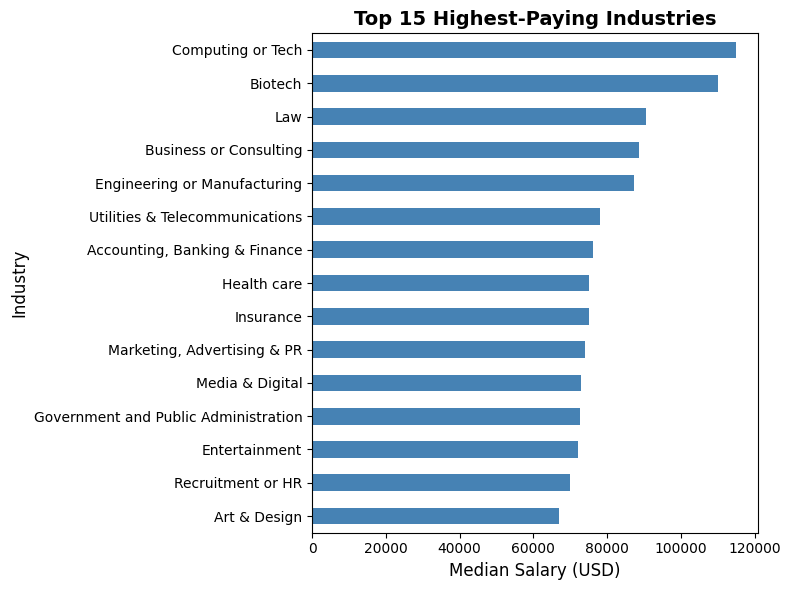

In [144]:
# I will be using an horizontal bar plot to visualise this.
plt.figure(figsize=(8, 6))
industry_salary.head(15).sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 Highest-Paying Industries', fontsize=14, fontweight='bold')
plt.ylabel('Industry', fontsize=12)
plt.xlabel('Median Salary (USD)', fontsize=12)
plt.tight_layout()
plt.show()

####**3.1.2. Key-Findings & Summary on Top-Paying Industries**

Among industries with at least 30 respondents, the **Computing or Tech** industry emerged as the highest paying, with \$115,000 as its median salary. **Biotech** followed at \$110,000, and in third place was **Law** at approximately \$91,000. **Business or Consulting** ranked fourth at approximately \$88,500.

Industries such as **Art & Design** and **Recruitment or HR** sit toward the lower end of this top-15 list (approximately \$67,000 to \$70,000), though they still represent solidly paid professional fields.

This suggests that specialised, technical, and professional-services industries command higher pay than general commercial, creative, or public-facing fields.

####**3.2. Salary Increase by Years of Experience**

This analysis was conducted to investigate whether median salary increases with years of overall professional experience.

In [145]:
#Q2. How does salary increase given years of experience?
experience_salary = df.groupby('Overall_Years_Experience_Midpoint')['Annual_Salary_USD'].median().sort_index()
experience_salary.head()

,Annual_Salary_USD
Overall_Years_Experience_Midpoint,
0.5,54000.0
3.0,58585.0
6.0,65000.0
9.0,73000.0
15.5,82550.0


####**3.2.1. Visualisation for Salary Increase by Years of Experience**

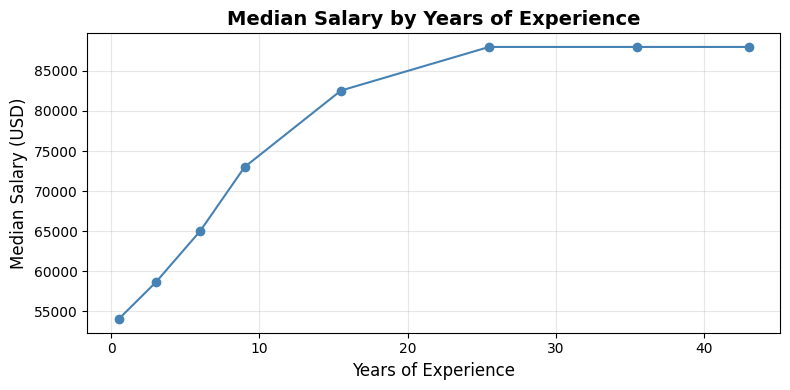

In [146]:
# For trends over time, it's best to use a line plot.
plt.figure(figsize=(8, 4))
plt.plot(experience_salary.index, experience_salary.values, marker='o', color='steelblue')
plt.title('Median Salary by Years of Experience', fontsize=14, fontweight='bold')
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Median Salary (USD)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

####**3.2.2. Key-Findings & Summary on Salary Increase by Years of Experience**

The result shows a strong positive relationship between years of experience and median salary. Median salary rises steadily from approximately \$54,000 for entry-level professionals (those with 1 year or less of experience) to about \$89,000 after 25 years. Beyond 25 years, salary growth slows down and plateaus, remaining around \$89,000 to \$90,000 from 35 - 42 years of experience.

This suggests that experience is associated with higher erning potential, particularly during the early and mid-career stages, while salary growth appears to level off at higher experience levels.

####**3.3. Same Role Salary Comparison in Different Locations**

This analysis was performed to find out how location can affect the salaries of professionals even if they perform the same role. Earlier, I explained that this analysis would be restricted to certain job titles with a reasonable amount of responses that cut across the UK, the US, and Canada.

In [147]:
#Q3. How do salaries compare for the same role in different locations?
top_titles = ['Software Engineer', 'Project Manager', 'Senior Software Engineer', 'Director']

location_salary = df[df['Job_Title'].isin(top_titles)].groupby(['Job_Title', 'Country'])['Annual_Salary_USD'].median().unstack()
location_salary.head()

Country,canada,united kingdom,united states
Job_Title,,,
Director,81400.0,101600.00,120500.0
Project Manager,57897.6,50800.00,82000.0
Senior Software Engineer,96200.0,85758.02,155000.0
Software Engineer,91020.0,60325.00,130000.0


####**3.3.1. Visualisation for Same-Role Salary Comparison Across Locations**

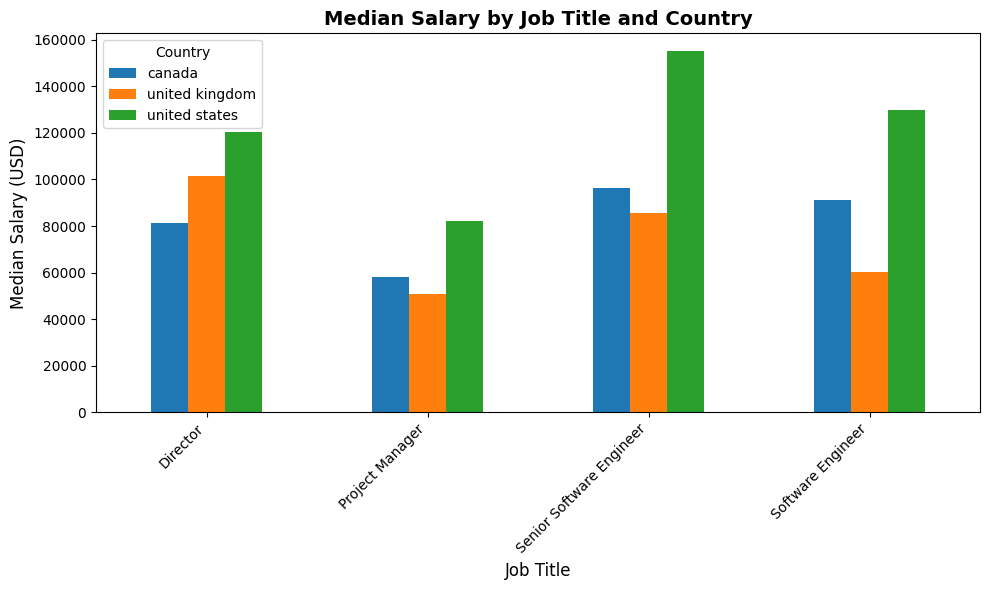

In [148]:
# Use a vertical bar plot for this.
location_salary.plot(kind='bar', figsize=(10, 6))
plt.title('Median Salary by Job Title and Country', fontsize=14, fontweight='bold')
plt.xlabel('Job Title', fontsize=12)
plt.ylabel('Median Salary (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Country')
plt.tight_layout()
plt.show()

####**3.3.2. Key-Findings & Summary on Same-Role Salary Comparison Across Locations**

This analysis reveals that the US pays more for every one of the four roles examined. The salary gap is more pronounced for **Senior Software Engineer**, where the US median (\$155,000) is nearly double Canada's (\$96,200) and almost twice the UK's (\$85,758). A similar pattern is seen for **Software Engineer** (\$130,000 US vs. \$91,020 Canada vs. \$60,325 UK) and **Director** (\$120,500 US vs. \$101,600 UK vs. \$81,400 Canada). For **Project Manager**, the US leads again with \$82,000, followed by Canada at \$57,897, and UK at the lowest with \$50,800.

The UK tends to pay the least for technical and managerial roles (Project Management, Senior Software Engineer, Software Engineer), while Canada is the lowest specifically for Director roles. This suggests that, even for identical job titles, US salaries significantly surpass those of equivalent roles in the UK and Canada. These differences could be caused by the differences in cost of living, market size, and industry demand across these three countries, although those factors were not directly examinedin this analysis.

####**3.4. Salary Differences by Gender & Years of Experience**

Earlier analysis has shown that salary actually changes with years of experience, but in addition to that, this analysis will confirm whether gender plays any role in how much professionals get paid.

In [149]:
# I didn't work on the Gender column when I was cleaning the data earlier, so I have little idea on what categories are present here.
# Before I run this analysis, I would like to check the Gender categories first to see what I would be working with.
df['Gender'].value_counts()

,count
Gender,
Woman,19894
Man,4839
Non-binary,700
Other or prefer not to answer,257
Prefer not to answer,1


**Note on Gender Categories:**

The result is clean and clear, so no additional cleaning is required.  However, the last two categories are extremely small, having 257 responses and 1 response respectively, and they somewhat have similar meaning ('Other or prefer not to answer' vs. 'Prefer not to answer'). To obtain a meaningful gender-based comparison, I would be excluding them from this analysis since they don't have any meaningful impact statistically.

Therefore, the categories for this analysis would be restricted to **Woman**, **Man**, and **Non-binary** since these ones have enough respondents to produce a reliable median.

In [150]:
#Q4. How much do salaries differ by gender and years of experience?
valid_genders = ['Woman', 'Man', 'Non-binary']

gender_exp_salary = df[df['Gender'].isin(valid_genders)].groupby(['Overall_Years_Experience_Midpoint', 'Gender'])['Annual_Salary_USD'].median().unstack()
gender_exp_salary.head()

Gender,Man,Non-binary,Woman
Overall_Years_Experience_Midpoint,,,
0.5,56500.0,36656.88,54000.0
3.0,67000.0,47150.00,57860.0
6.0,76220.0,51910.00,65000.0
9.0,90000.0,56500.00,71379.0
15.5,107000.0,69000.00,79600.0


####**3.4.1. Visualisation for Salary Differences by Gender & Overall Years of Experience**

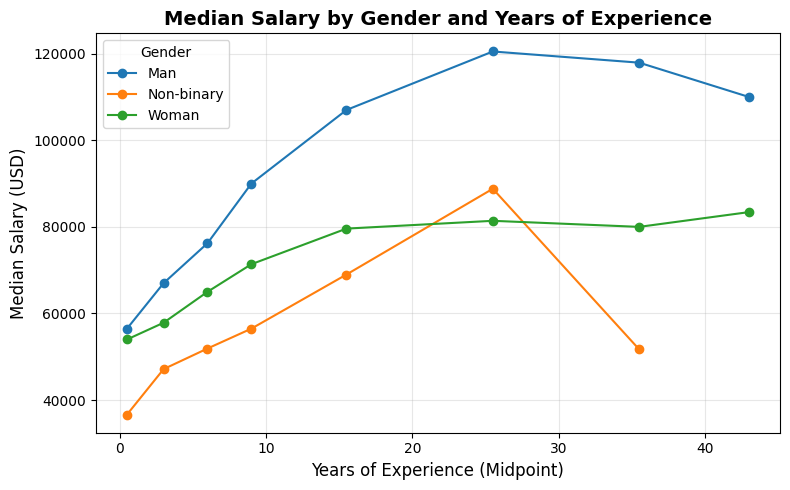

In [151]:
# Use line plot.
gender_exp_salary.plot(marker='o', figsize=(8, 5))
plt.title('Median Salary by Gender and Years of Experience', fontsize=14, fontweight='bold')
plt.xlabel('Years of Experience (Midpoint)', fontsize=12)
plt.ylabel('Median Salary (USD)', fontsize=12)
plt.legend(title='Gender')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [152]:
# I am curious to know why there is an extreme drop in the annual salary of the Non-binary group after about 26 years of experience.
df.groupby(['Overall_Years_Experience_Midpoint', 'Gender'])['Annual_Salary_USD'].count().unstack()

# Perhaps, the decline is due to the low number of responses (only 2) in that category after 25.5 years of experience.

Gender,Man,Non-binary,Other or prefer not to answer,Prefer not to answer,Woman
Overall_Years_Experience_Midpoint,,,,,
0.5,96.0,22.0,6.0,1.0,325.0
3.0,475.0,128.0,25.0,NaN,2058.0
6.0,749.0,192.0,51.0,NaN,3453.0
9.0,815.0,146.0,46.0,NaN,3967.0
15.5,1769.0,167.0,80.0,NaN,6866.0
25.5,732.0,43.0,35.0,NaN,2535.0
35.5,168.0,2.0,12.0,NaN,611.0
43.0,35.0,NaN,2.0,NaN,79.0


####**3.4.2. Key-Findings & Summary on Salary Differences by Gender & Overall Years of Experience**

Salary by gender shows a widening gap through the first two decades of a career, followed by a partial reversal.

**Man** respondents have the strongest and most sustained salary growth, rising from about \$56,500 at entry level to a peak of roughly \$112,000 around 25 years of experience, before declining to about \$98,000 among the most experienced respondents (40+ years).

**Woman** respondents have a steadier but more modest growth, plateauing around \$73,000 to \$76,000 from roughly 15 years of experience onward.

**Non-binary** respondents start with the lowest salaries (around \$36,500 at entry level) but show notable growth mid-career, briefly surpassing the median salary of  **Woman** around the 25-year mark at approximately \$83,000, before dropping sharply to around \$44,000 among the most experienced respondents. This drop is likely due to the small sample size of respondents at that experience level.

Overall, the difference in median salary between the gender groups is largest in the 20-30 year experience range, where the median salary for men substantially exceeds the other two categories. At both the earliest and the latest career stages, the difference in median salaries between all groups are comparatively smaller.

####**3.5. Correlation of Race and Education Level with Salary**

This analysis questions whether **race** and **education** are associated with differences in salary.

In [153]:
#Q5. How do factors like race and education level correlate with salary?

# Start with Race.

####**3.5.1. Race and Salary**

Earlier during data cleaning, I created seven new columns for race because the initial entry was a multi-select field and some of the respondents had selected multiple races.

To make analysis easier, I had to separate each of the race options into new columns and map all the responses from the general race column to that of the corresponding new one, so that even if a respondent selected more than one race, all the entries would be properly accounted for.

These new columns are: **'Race_white', 'Race_black', 'Race_asian', 'Race_hispanic_latino', 'Race_middle_eastern', 'Race_native_american', and 'Race_another_option_not_l'**.

This analysis will be based on these seven columns.

In [154]:
# Shorten column names to more readable labels and calculate the median salary for each race category.
race_columns = [
    'Race_white',
    'Race_black',
    'Race_asian',
    'Race_hispanic_latino',
    'Race_middle_eastern',
    'Race_native_american',
    'Race_another_option_not_l'
]

race_salary = {}

for race in race_columns:
  race_salary[race] = df.loc[df[race] == 1, 'Annual_Salary_USD'].median()

race_salary = (
    pd.Series(race_salary)
    .rename({
        'Race_white': 'White',
        'Race_black': 'Black',
        'Race_asian': 'Asian',
        'Race_hispanic_latino': 'Hispanic/Latino',
        'Race_middle_eastern': 'Middle Eastern',
        'Race_native_american': 'Native American',
        'Race_another_option_not_l': 'Others'
    })
    .sort_values(ascending=False)
)

race_salary = race_salary.rename('Annual_Salary_USD').to_frame()
race_salary.index.name = 'Race'

race_salary

,Annual_Salary_USD
Race,
Asian,87500.0
Others,80000.0
Middle Eastern,79000.0
Black,75000.0
White,74000.0
Hispanic/Latino,74000.0
Native American,71150.0


####**3.5.1.1. Visualisation of the Relationship Between Race and Salary**

<Figure size 1000x600 with 0 Axes>

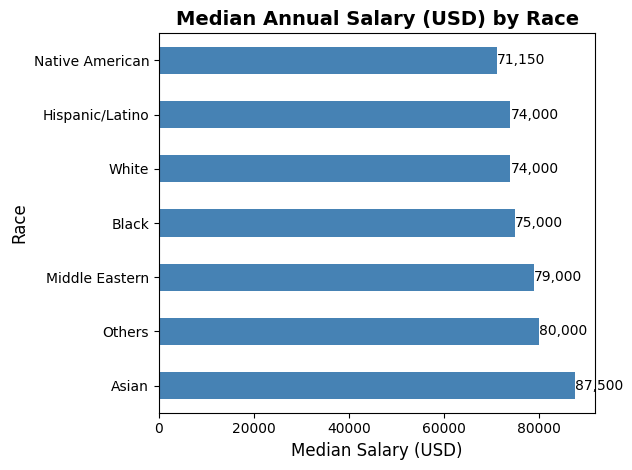

In [155]:
# Use an horizontal bar plot.

plt.figure(figsize=(10, 6))
race_salary.plot(kind='barh', color='steelblue')
plt.title('Median Annual Salary (USD) by Race', fontsize=14, fontweight='bold')
plt.xlabel('Median Salary (USD)', fontsize=12)
plt.ylabel('Race', fontsize=12)

# Add salary labels to each bar.
for i, salary in enumerate(race_salary['Annual_Salary_USD']):
    plt.text(salary, i, f'{salary:,.0f}', ha='left', va='center', fontsize=10)

plt.legend().remove()
plt.tight_layout()
plt.show()

####**3.5.1.2. Key-Findings & Summary on the Relationship Between Race and Salary**

From the bar plot above, respondents who selected Asian had the highest median annual salary **(\$87,500)**, followed by respondents in the 'Others' category. White and Hispanic/Latino respondents both had similar median salaries **(\$74,000)**, while Native American respondents had the lowest median salary among the groups analysed **(\$71,150)**.

These results describe the survey sample and should not be interpreted as evidence that race alone determines salary.

####**3.5.2. Education Level and Salary**

In [156]:
# Calculate the median salary for each level of education.
education_salary = df.groupby('Education')['Annual_Salary_USD'].median().sort_values(ascending=False)
education_salary

/tmp/ipykernel_4123/753381157.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  education_salary = df.groupby('Education')['Annual_Salary_USD'].median().sort_values(ascending=False)


,Annual_Salary_USD
Education,
"Professional degree (MD, JD, etc.)",113000.0
PhD,91000.0
Master's degree,78000.0
College degree,71000.0
Some college,60000.0
High School,53170.0


####**3.5.2.1. Visualisation of the Relationship Between Education Level and Salary**

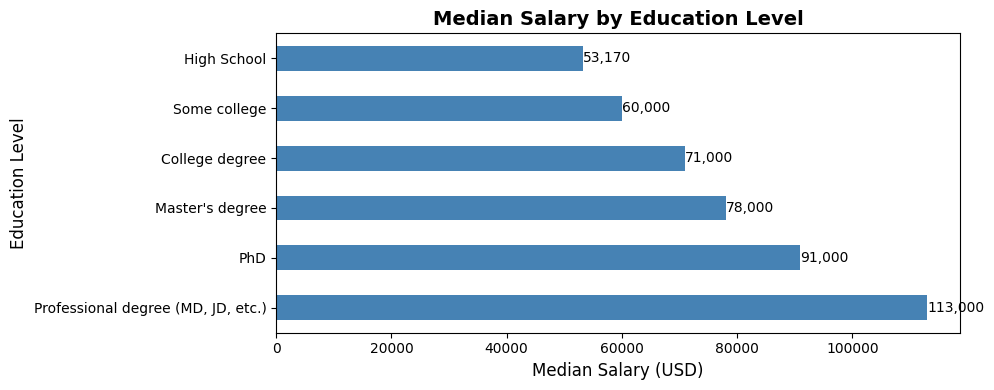

In [157]:
# Use an horizontal bar plot.
plt.figure(figsize=(10, 4))
education_salary.plot(kind='barh', color='steelblue')
plt.title('Median Salary by Education Level', fontsize=14, fontweight='bold')
plt.xlabel('Median Salary (USD)', fontsize=12)
plt.ylabel('Education Level', fontsize=12)

# Add salary labels.
for i, salary in enumerate(education_salary):
    plt.text(salary, i, f'{salary:,.0f}', ha='left', va='center', fontsize=10)

plt.legend().remove()
plt.tight_layout()
plt.show()

####**3.5.2.2. Key-Findings & Summary on the Relationship Between Education Level and Salary**

This analysis indicates a positive relationship between education level and salary. Respondents with **professional degrees (MD, JD, etc.)** had the highest median annual salary of **\$113,000**, followed by those with a **PhD** **(\$91,000)** and a **Master's degree** **(\$78,000)**. Respondents with only a **High School** education earned the lowest median salary **(\$53,170)**.

Overall, the findings suggest that higher educational attainment is associated with higher median earnings.

####**3.6. 'Sweet spot" Between Total Work Experience and Field Experience**

In simpler words, what this analysis is trying to uncover is whether having more experience in a specific field leads to higher salaries or if having a broader work experience (even outside a respondent's field) is more valuable.

It asks if there is an "ideal balance" between the two.

In [158]:
#Q6. Is there a "sweet spot" between total work experience and years in the specific field — i.e. does having more years in-role beyond overall experience relate differently to salary than the reverse?

# Get the median salary by overall years of experience.
overall_salary = df.groupby('Overall_Years_Experience')['Annual_Salary_USD'].median().sort_index()
overall_salary

/tmp/ipykernel_4123/3824339526.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  overall_salary = df.groupby('Overall_Years_Experience')['Annual_Salary_USD'].median().sort_index()


,Annual_Salary_USD
Overall_Years_Experience,
1 year or less,54000.0
2 - 4 years,58585.0
5-7 years,65000.0
8 - 10 years,73000.0
11 - 20 years,82550.0
21 - 30 years,88000.0
31 - 40 years,88000.0
41 years or more,88000.0


In [159]:
# Median salary by years in specific field.
field_salary = df.groupby('Field_Years_Experience')['Annual_Salary_USD'].median().sort_index()
field_salary

/tmp/ipykernel_4123/226366879.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  field_salary = df.groupby('Field_Years_Experience')['Annual_Salary_USD'].median().sort_index()


,Annual_Salary_USD
Field_Years_Experience,
1 year or less,52000.0
2 - 4 years,60000.0
5-7 years,71000.0
8 - 10 years,80000.0
11 - 20 years,90000.0
21 - 30 years,100000.0
31 - 40 years,99500.0
41 years or more,100796.0


####**3.6.1. Visualisation of the Relationship Between Total Work Experience & Median Salary**

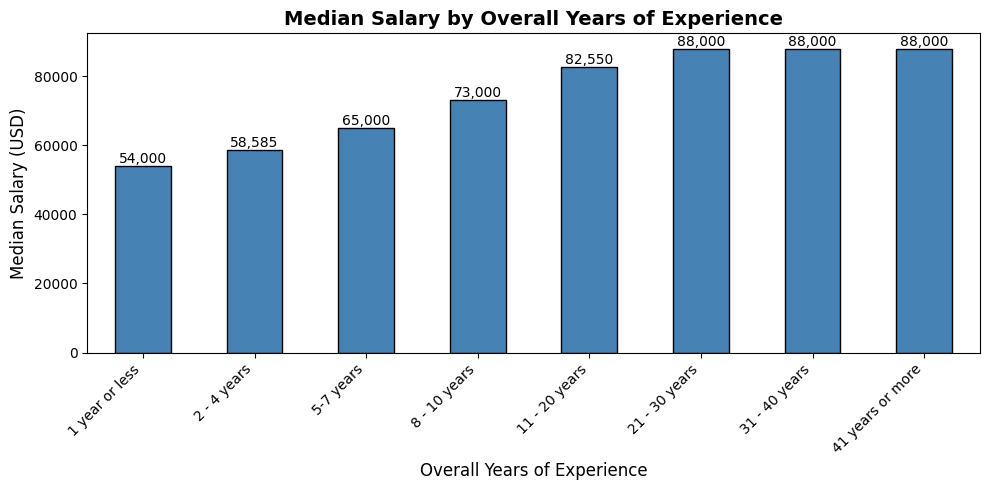

In [160]:
# Vertical bar plot.

plt.figure(figsize=(10, 5))

overall_salary.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Median Salary by Overall Years of Experience', fontsize=14, fontweight='bold')
plt.xlabel('Overall Years of Experience', fontsize=12)
plt.ylabel('Median Salary (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add salary labels.
for i, salary in enumerate(overall_salary):
    plt.text(i, salary, f'{salary:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

####**3.6.1.1. Visualisation of the Relationship Between Field Experience & Median Salary**

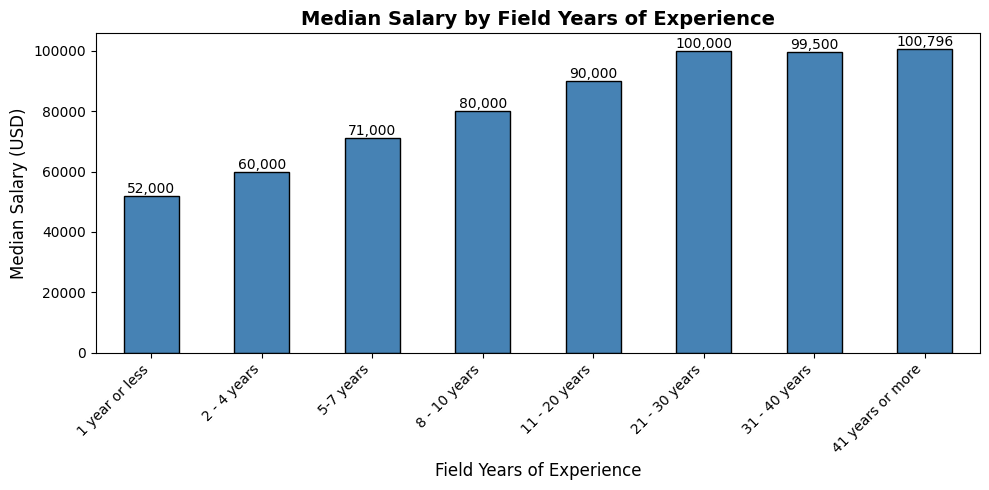

<Figure size 640x480 with 0 Axes>

In [161]:
# Vertical Bar Plot

plt.figure(figsize=(10, 5))

field_salary.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Median Salary by Field Years of Experience', fontsize=14, fontweight='bold')
plt.xlabel('Field Years of Experience', fontsize=12)
plt.ylabel('Median Salary (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add salary labels.
for i, salary in enumerate(field_salary):
    plt.text(i, salary, f'{salary:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

####**3.6.2. Key-Findings & Summary on the Relationship Between Total Work Experience & Field Experience**

The two charts suggest that median salaries are generally higher at comparable experience levels when experience is measured within a specific field rather than as total professional experience. This may indicate that specialisation and expertise within a particular field may have a stronger influence on earnings than simply accumulating years in the workforce, although it doesn't establish that field experience directly causes higher salaries.

These findings motivate a deeper investigation into whether the **difference between total work experience and field experience (Experience Gap)** is also associated with salary, and whether there exists an optimal balance ("sweet spot") between broad work experience and specialised experience.

####**3.6.3. Is There A Sweet-Spot Between Total Experience & Work Experience?**

To analyse this question, I would be making use of the experience gap column. It is important to note that **234 responses** reported more years of experience in their field than their total years of professional experience, resulting in some negative values in the gap column. These observations would be treated as inconsistent responses and would be excluded from the experience-gap analysis.

In [162]:
# Keep only realistic experience gap values.
gap_df = df[df['Experience_Gap'] >= 0].copy()
gap_df.shape

(25460, 27)

In [163]:
# I want to find out how many unique gap values there are.
gap_df['Experience_Gap'].nunique()

27

In [164]:
# Create grouped experience-gap categories then calculate the median salary for each category.

bins = [-0.1, 0, 5, 10, 20, gap_df['Experience_Gap'].max()]

labels = ['No gap', '0.5-5 years', '5.5-10 years', '10.5-20 years', 'Over 20 years']

gap_df['Gap_Category'] = pd.cut(gap_df['Experience_Gap'], bins=bins, labels=labels)

gap_df['Gap_Category'] = pd.cut(
    gap_df['Experience_Gap'],
    bins=bins,
    labels=labels
)

gap_salary = (gap_df.groupby('Gap_Category', observed=False)['Annual_Salary_USD'].median().reset_index())
gap_salary

,Gap_Category,Annual_Salary_USD
0,No gap,80000.00
1,0.5-5 years,64000.00
2,5.5-10 years,75000.00
3,10.5-20 years,65000.00
4,Over 20 years,57466.76


####**3.6.3.1. Visualisation of Experience Gap & Median Salary**

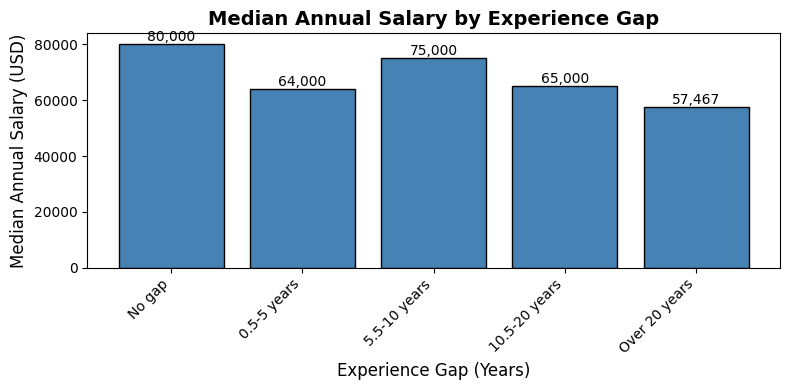

In [165]:
# Use a bar plot.

plt.figure(figsize=(8, 4))

plt.bar(gap_salary['Gap_Category'], gap_salary['Annual_Salary_USD'], color='steelblue', edgecolor='black')
plt.title('Median Annual Salary by Experience Gap', fontsize=14, fontweight='bold')
plt.xlabel('Experience Gap (Years)', fontsize=12)
plt.ylabel('Median Annual Salary (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right')

for i, salary in enumerate(gap_salary['Annual_Salary_USD']):
    plt.text(i, salary, f'{salary:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

**3.6.3.2. Key-Findings & Summary on the Sweet-Spot Between Field Experience & Overall Experience**

The **No gap** category had the highest median salary (**\$80,000**), suggesting that respondents whose overall and field experience were approximately aligned had the highest median salary among the groups analysed.

There is a small rebound from the **0.5-5 year gap category** to the **5.5-10 year gap category**, so the relationship is not perfectly linear. But generally, the results largely suggest that larger differences between overall and field experience were generally associated with lower median salaries in this dataset, although the relationship was not perfectly linear.

Those with gaps exceeding 20 years had the lowest median salary (**\$57,467**).

####**4.0. Summary and Conclusion**

####**4.1. Summary**

The **Ask A Manager Salary Survey (2021)** data, collected through an open online survey, reflects the realities of crowd-sourced data. There were missing values, inconsistency with entries, whitespaces, and more throughout the data.

After a series of thorough data cleaning, the **'Country'** column was restricted to the top three **(the US, the UK, and Canada)**. The **'Currency'** column was subsequently restricted to **USD, GBP, and CAD**, which are the currencies used in each of those countries respectively. GBP and CAD were converted to their equivalents in USD.

'Job_Titles' and 'Industry' also got restricted to the categories that had a substantial amount of entries that could be used for standard analysis. **'Job_Titles'** got restricted to: **Software Engineer, Project Manager, Senior Software Engineer, and Director**, while **'Industry'** got restricted to the ones that had the highest number of entries (top 15), which include: **Computing or Tech, Biotech, Law, Insurance, Healthcare, Art & Design, Recruitment or HR, e.t.c**. **'Gender'** got restricted to **Man, Woman, and Non-Binary**.

Some analyses were then performed to obtain useful insights on how the annual salaries of various professionals were affected by factors such as location, race, gender, and education, and if having more overall work or field experience had any impact on the annual salaries of professionals.

At the end, the analysis found that Computing or Tech had the highest median salary among the industries analysed. Median salary also generally increased with years of professional experience, although the increase became less pronounced at higher experience levels.

Salary comparisons across the United States, United Kingdom, and Canada showed substantial differences for the same job titles, with the United States generally recording higher median salaries for the roles examined.

The gender and experience analysis showed differences in median salary between the groups, with the size of these differences varying across experience levels. The experience-gap analysis also showed that respondents with no gap between overall and field experience had the highest median salary among the categories analysed, while those with gaps exceeding 20 years had the lowest median salary.

####**4.2. Conclusion**

Overall, the analysis demonstrates clear differences in salary associated with **industry, years of experience, location, gender, and the relationship between overall and field-specific experience**.

The findings suggest that experience and industry are important factors associated with salary levels, while location and gender are also associated with substantial differences in median earnings. However, these relationships are observational and do not establish that any individual factor directly causes differences in salary.

The project also demonstrated the use of Python and Pandas for data cleaning, transformation, exploratory analysis, grouping, aggregation, and visualisation. The analysis provided practical experience in turning a large, messy dataset into structured information that can be used to identify salary patterns and support data-driven interpretation.